<a href="https://colab.research.google.com/github/amrut23ds48/ml/blob/main/davpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
data_size = 200

age = np.random.randint(18, 60, size=data_size)
steps = np.random.randint(2000, 15000, size=data_size)
sleep = np.random.uniform(5, 9, size=data_size)

# 2. Creating a Relationship (The "Secret" Formula)
# Calories = (Steps * 0.15) + (Age * -2) + (Sleep * 50) + Base_Metabolism + Noise
noise = np.random.normal(0, 50, size=data_size)
calories = (steps * 0.12) - (age * 1.5) + (sleep * 40) + 1200 + noise

# 3. Creating a Logical Category (Classification)
# If steps > 10000 -> Elite, > 5000 -> Active, else Sedentary
fitness_cat = []
for s in steps:
    if s > 10000: fitness_cat.append('Elite')
    elif s > 5000: fitness_cat.append('Active')
    else: fitness_cat.append('Sedentary')

df = pd.DataFrame({
    'Age': age,
    'Daily_Steps': steps,
    'Sleep_Hours': sleep.round(1),
    'Calories_Burned': calories.astype(int),
    'Fitness_Category': fitness_cat
})

df.to_csv('smart_fitness_data.csv', index=False)

Model Coefficient (Slope): 0.1219
Model Intercept: 1408.5218
Mean Squared Error: 6590.46
R2 Score (Accuracy): 0.9706


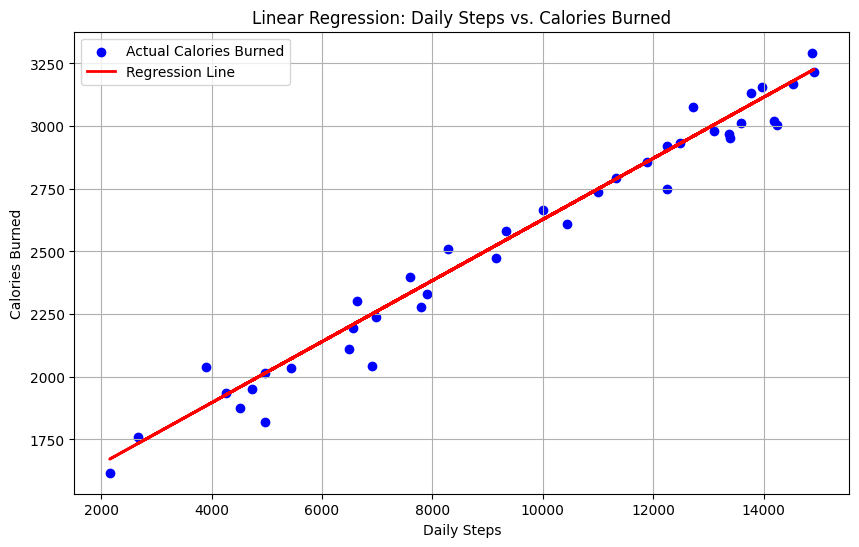

In [2]:
#3 linear
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

df = pd.read_csv('smart_fitness_data.csv')

X = df[['Daily_Steps']]
y = df['Calories_Burned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Model Intercept: {model.intercept_:.4f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R2 Score (Accuracy): {r2:.4f}")

# Plotting the regression
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, color='blue', label='Actual Calories Burned')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Daily Steps')
plt.ylabel('Calories Burned')
plt.title('Linear Regression: Daily Steps vs. Calories Burned')
plt.legend()
plt.grid(True)
plt.show()


--- Multiple Linear Regression Results ---
Model Coefficients: [ 0.12091636 -1.71974326 42.00319938]
Corresponding Features: ['Daily_Steps', 'Age', 'Sleep_Hours']
Model Intercept: 1190.9966
Mean Squared Error: 3788.04
R2 Score (Accuracy): 0.9831


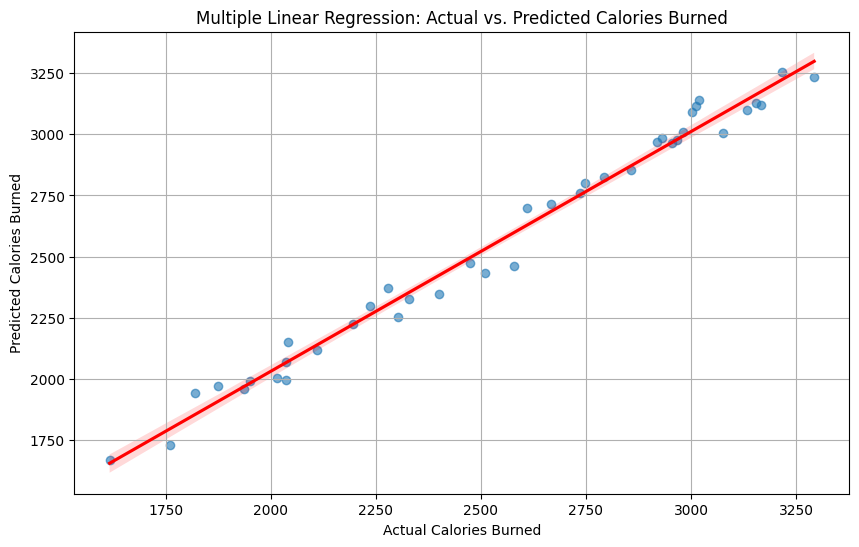

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('smart_fitness_data.csv')

# Define features (X) and target (y) for multiple linear regression
X_multi = df[['Daily_Steps', 'Age', 'Sleep_Hours']]
y_multi = df['Calories_Burned']

# Split data into training and testing sets
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

# Initialize and train the multiple linear regression model
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

# Make predictions on the test set
y_pred_multi = model_multi.predict(X_test_multi)

# Evaluate the model
mse_multi = mean_squared_error(y_test_multi, y_pred_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print("\n--- Multiple Linear Regression Results ---")
print(f"Model Coefficients: {model_multi.coef_}")
print(f"Corresponding Features: {X_multi.columns.tolist()}")
print(f"Model Intercept: {model_multi.intercept_:.4f}")
print(f"Mean Squared Error: {mse_multi:.2f}")
print(f"R2 Score (Accuracy): {r2_multi:.4f}")

# Plotting actual vs. predicted values for multiple linear regression
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test_multi, y=y_pred_multi, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.title('Multiple Linear Regression: Actual vs. Predicted Calories Burned')
plt.grid(True)
plt.show()


--- Synthetic Time Series Data Head ---
            Daily_Steps
2022-01-01         5248
2022-01-02         4957
2022-01-03         5376
2022-01-04         5840
2022-01-05         4987


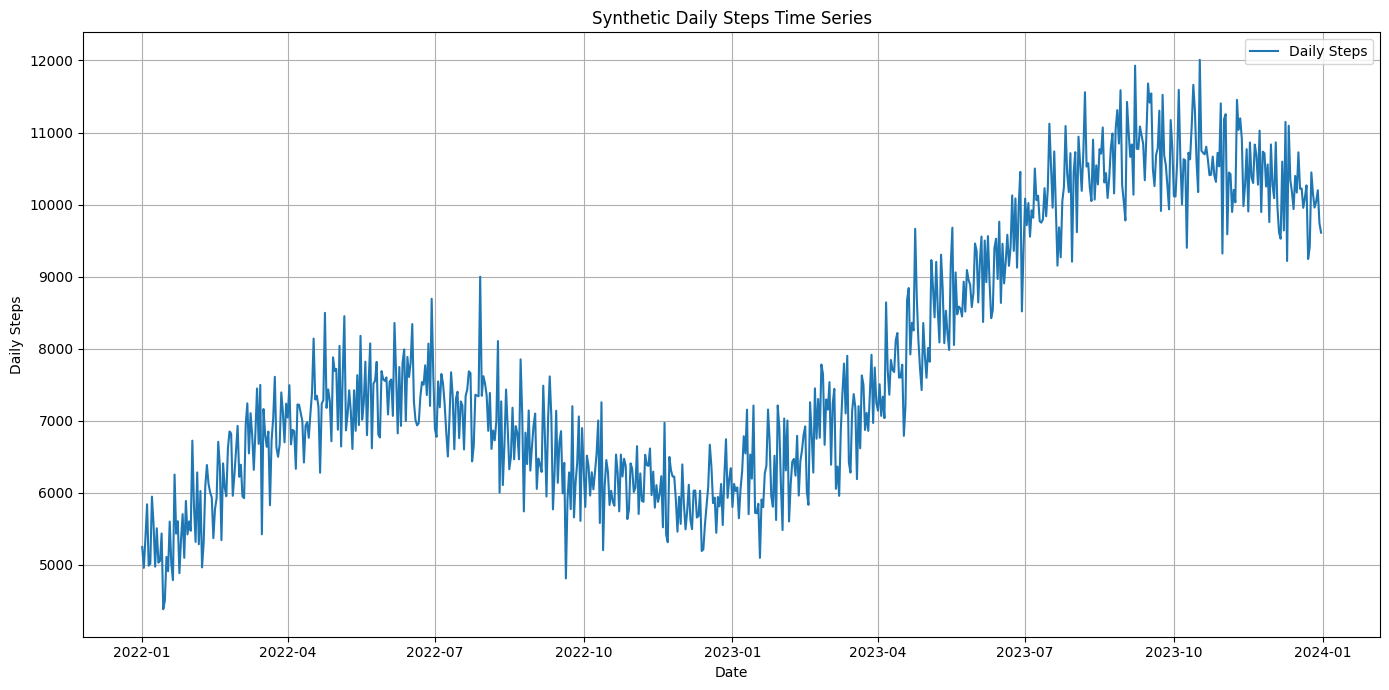

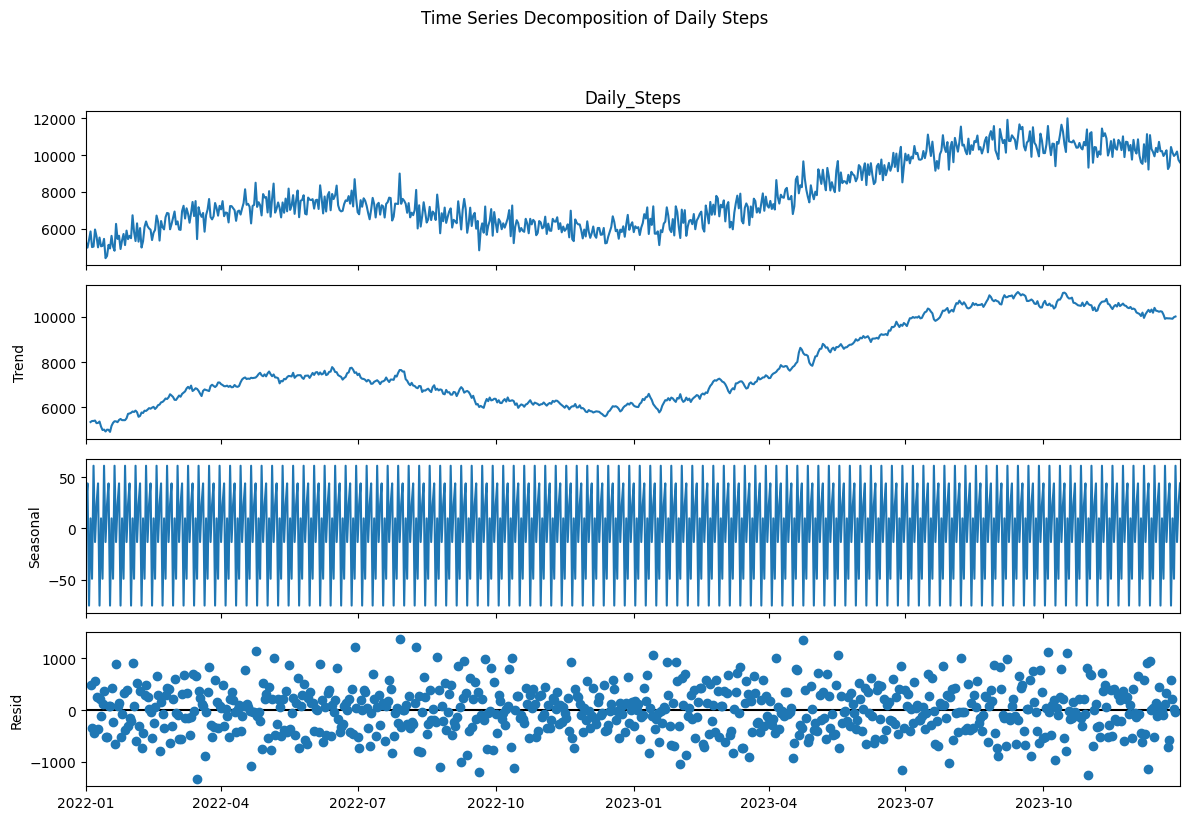

In [4]:
#timeseries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Generate a synthetic time series dataset
# Let's create a daily time series for 2 years
date_range = pd.date_range(start='2022-01-01', periods=730, freq='D')

# Generate some 'steps' data with a trend and seasonality
np.random.seed(42)
trend = np.linspace(5000, 10000, len(date_range))  # Upward trend
seasonality = 1500 * np.sin(np.linspace(0, 3 * np.pi, len(date_range))) # Seasonal pattern
noise = np.random.normal(0, 500, len(date_range)) # Random fluctuations

time_series_steps = (trend + seasonality + noise).astype(int)
time_series_steps[time_series_steps < 0] = 0 # Ensure no negative steps

time_series_df = pd.DataFrame({'Daily_Steps': time_series_steps}, index=date_range)

print("\n--- Synthetic Time Series Data Head ---")
print(time_series_df.head())

# 2. Visualization of the original time series
plt.figure(figsize=(14, 7))
plt.plot(time_series_df.index, time_series_df['Daily_Steps'], label='Daily Steps')
plt.title('Synthetic Daily Steps Time Series')
plt.xlabel('Date')
plt.ylabel('Daily Steps')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



decomposition = seasonal_decompose(time_series_df['Daily_Steps'], model='additive', period=7)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Time Series Decomposition of Daily Steps', y=1.02) # Add a main title
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

Generating simple visualizations with Python libraries...


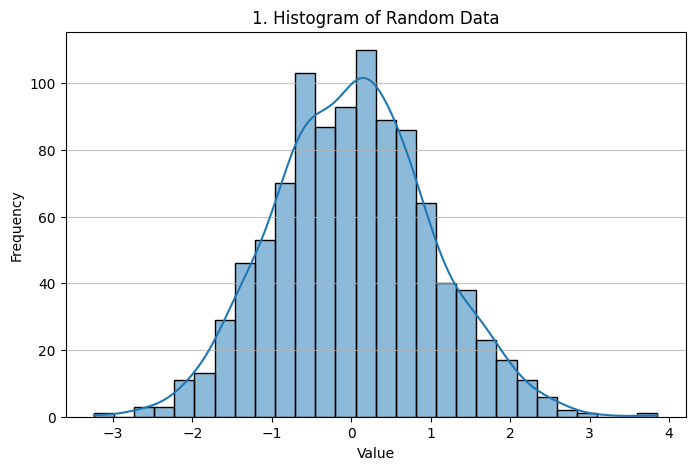

/tmp/ipykernel_8564/1377494189.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=counts, palette='viridis')


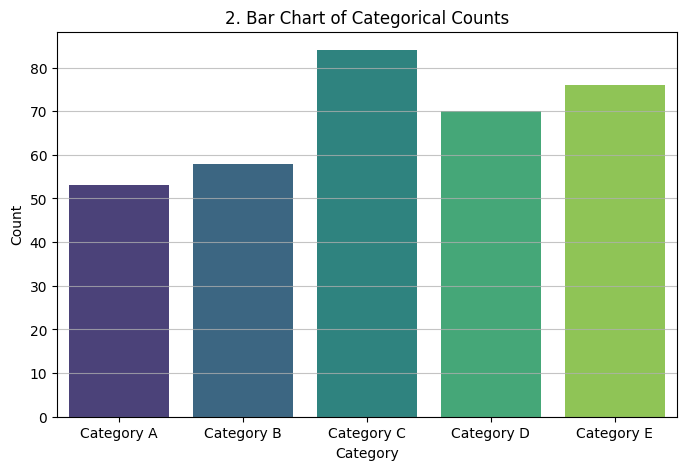

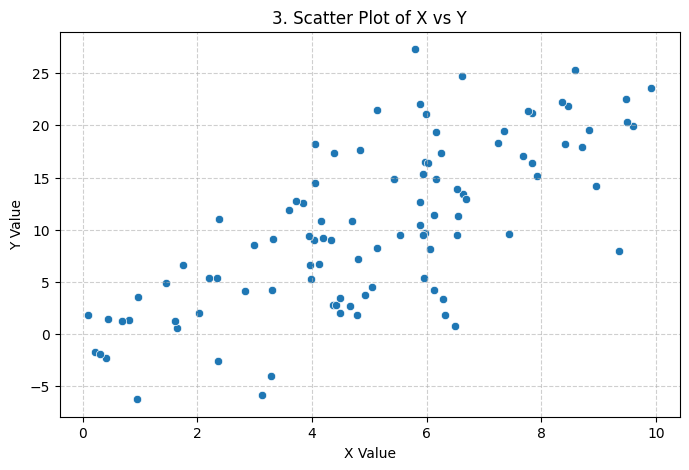

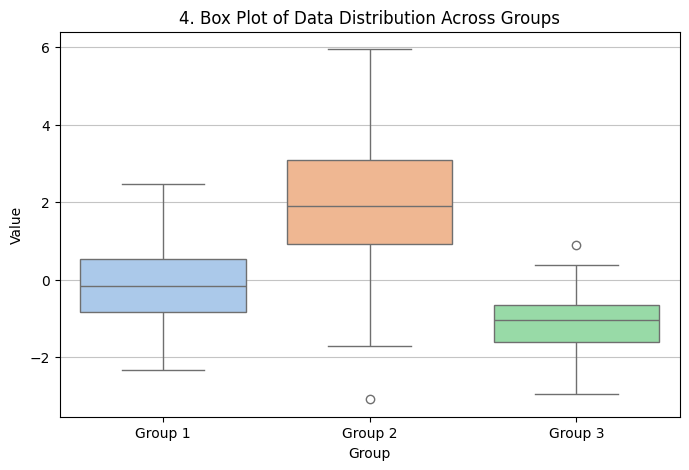

Visualizations complete!


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set a random seed for reproducibility
np.random.seed(42)

print("Generating simple visualizations with Python libraries...")

# 1. Histogram: Distribution of a single numerical variable
# Generate 1000 random numbers from a normal distribution
data_hist = np.random.randn(1000)
plt.figure(figsize=(8, 5))
sns.histplot(data_hist, kde=True)
plt.title('1. Histogram of Random Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 2. Bar Chart: Comparison of categorical data
# Generate counts for a few categories
categories = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
counts = np.random.randint(10, 100, size=len(categories))

plt.figure(figsize=(8, 5))
sns.barplot(x=categories, y=counts, palette='viridis')
plt.title('2. Bar Chart of Categorical Counts')
plt.xlabel('Category')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.75)
plt.show()

# 3. Scatter Plot: Relationship between two numerical variables
# Generate two sets of correlated random data
x_scatter = np.random.rand(100) * 10
y_scatter = 2 * x_scatter + np.random.randn(100) * 5

plt.figure(figsize=(8, 5))
sns.scatterplot(x=x_scatter, y=y_scatter)
plt.title('3. Scatter Plot of X vs Y')
plt.xlabel('X Value')
plt.ylabel('Y Value')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 4. Box Plot: Distribution and outliers for different groups
# Generate data for three groups
data_box = [np.random.normal(0, 1, 100), np.random.normal(2, 1.5, 100), np.random.normal(-1, 0.8, 100)]
labels_box = ['Group 1', 'Group 2', 'Group 3']

plt.figure(figsize=(8, 5))
sns.boxplot(data=data_box, palette='pastel')
plt.xticks(ticks=range(len(labels_box)), labels=labels_box)
plt.title('4. Box Plot of Data Distribution Across Groups')
plt.xlabel('Group')
plt.ylabel('Value')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("Visualizations complete!")

In [6]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Set a random seed for reproducibility
np.random.seed(42)

print("Generating simple Plotly visualizations...")

# 1. Histogram: Distribution of a single numerical variable
data_hist = np.random.randn(1000) # Generate 1000 random numbers from a normal distribution
df_hist = pd.DataFrame({'Value': data_hist})

fig_hist = px.histogram(df_hist, x="Value", nbins=50, title='1. Histogram of Random Data')
fig_hist.update_layout(bargap=0.1) # Add a small gap between bars for better visualization
fig_hist.show()

# 2. Bar Chart: Comparison of categorical data
categories = ['Category A', 'Category B', 'Category C', 'Category D', 'Category E']
counts = np.random.randint(10, 100, size=len(categories))
df_bar = pd.DataFrame({'Category': categories, 'Count': counts})

fig_bar = px.bar(df_bar, x='Category', y='Count', title='2. Bar Chart of Categorical Counts')
fig_bar.show()

# 3. Scatter Plot: Relationship between two numerical variables
x_scatter = np.random.rand(100) * 10
y_scatter = 2 * x_scatter + np.random.randn(100) * 5
df_scatter = pd.DataFrame({'X Value': x_scatter, 'Y Value': y_scatter})

fig_scatter = px.scatter(df_scatter, x='X Value', y='Y Value', title='3. Scatter Plot of X vs Y')
fig_scatter.show()

# 4. Box Plot: Distribution and outliers for different groups
data_box_g1 = np.random.normal(0, 1, 100)
data_box_g2 = np.random.normal(2, 1.5, 100)
data_box_g3 = np.random.normal(-1, 0.8, 100)

df_box = pd.DataFrame({
    'Value': np.concatenate([data_box_g1, data_box_g2, data_box_g3]),
    'Group': ['Group 1']*100 + ['Group 2']*100 + ['Group 3']*100
})

fig_box = px.box(df_box, x='Group', y='Value', title='4. Box Plot of Data Distribution Across Groups')
fig_box.show()

print("Plotly visualizations complete!")

Generating simple Plotly visualizations...


Plotly visualizations complete!
